<a href="https://colab.research.google.com/github/azimgilo/airline-disruption-analytics-sql/blob/main/Airline_Passenger_Operations_%26_Disruption_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Passenger Operations & Disruption Analytics (SQL Case Study)

**Domain Context:** Korean Air Passenger Service & Operational Analytics  
**Tech Stack:** Python, DuckDB (In-Memory SQL Engine), Pandas  
**Target Schema:** Relational Star-Schema (`stg_flights`, `dim_passengers`, `fact_booking_itineraries`)

---

### Step 1: Environment Setup & Tooling Selection

**What I did:**  
Installed and imported `duckdb` and `pandas` into the Python runtime environment, establishing an in-memory SQL session engine.

**Why I did it:**  
Traditional standalone SQL databases (like PostgreSQL or MySQL) require server configuration, user management, and heavy data ingestion setup. DuckDB provides an ultra-fast, zero-management analytical engine that runs full ANSI SQL directly inside Python. It processes millions of rows in milliseconds using columnar execution, allowing direct operations on raw CSV files while maintaining standard SQL syntax (`CTEs`, `Window Functions`, `JOINs`).

In [4]:
# ==========================================
# STEP 1: Environment Setup
# ==========================================
import os
import urllib.request
import pandas as pd
import duckdb

# Initialize an in-memory DuckDB analytical SQL connection
con = duckdb.connect()

print("✅ Step 1 Complete: DuckDB SQL engine initialized successfully!")

✅ Step 1 Complete: DuckDB SQL engine initialized successfully!


---

### Step 2: Automated Data Acquisition & Streaming Preview

**What I did:**  
Automated the retrieval of raw airline operational data from the `vincentarelbundock/Rdatasets` repository mirror using Python's `requests` library, saving it directly to a local `raw_data/` directory. Then, utilized DuckDB's `read_csv_auto()` combined with a `LIMIT 10` clause to stream a fast, lazy preview of the dataset.

**Why I did it:**  
Automating data ingestion directly in Python ensures 100% pipeline reproducibility without requiring manual file uploads or browser downloads. Sourcing from a verified GitHub mirror endpoint bypasses restrictive cloud storage 403 Forbidden filters. Furthermore, raw aviation datasets contain extensive operational records—leveraging DuckDB's lazy-execution engine to stream only the first 10 rows allows us to instantly inspect raw schema structures, unformatted fields, and data types without loading multi-gigabyte files into RAM.

In [11]:
# ==========================================
# STEP 2: Ingestion & Lazy Preview (Verified Live URL)
# ==========================================
import os
import requests
import duckdb

# 1. Create directory for raw landing data
raw_dir = "raw_data"
os.makedirs(raw_dir, exist_ok=True)
csv_filepath = os.path.join(raw_dir, "raw_flights.csv")

# 2. Automated Python download using verified NYC Flights raw repository
print("⬇️ Fetching raw flight dataset via Python...")

# Verified direct raw CSV URL from a stable Rdatasets mirror
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/nycflights13/flights.csv"

response = requests.get(url, stream=True)
response.raise_for_status()

with open(csv_filepath, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("✅ Raw dataset saved to 'raw_data/raw_flights.csv'")

# 3. Stream & Preview First 10 Rows (Lazy Execution)
con = duckdb.connect()

preview_query = f"""
SELECT *
FROM read_csv_auto('{csv_filepath}')
LIMIT 10;
"""

df_preview = con.execute(preview_query).df()

print(f"\n✅ Step 2 Complete: Previewed Raw Data ({len(df_preview.columns)} columns detected)")
display(df_preview)


⬇️ Fetching raw flight dataset via Python...
✅ Raw dataset saved to 'raw_data/raw_flights.csv'

✅ Step 2 Complete: Previewed Raw Data (20 columns detected)


,rownames,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,1,2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 10:00:00+00:00
1,2,2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 10:00:00+00:00
2,3,2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 10:00:00+00:00
3,4,2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 10:00:00+00:00
4,5,2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 11:00:00+00:00
5,6,2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 10:00:00+00:00
6,7,2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 11:00:00+00:00
7,8,2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 11:00:00+00:00
8,9,2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 11:00:00+00:00
9,10,2013,1,1,558,600,-2,753,745,8,AA,301,N3ALAA,LGA,ORD,138,733,6,0,2013-01-01 11:00:00+00:00


---

### Step 3: SQL Data Cleaning, Formatting & Operational Staging

**What I did:**  
Wrote a multi-stage SQL transformation script (`CREATE OR REPLACE TABLE stg_flights`) adapting to the `nycflights13` dataset structure. This included constructing standard ISO dates from year/month/day columns, left-padding raw integer time records (e.g., `805` -> `'0805'`), handling missing values using `COALESCE()`, and deriving cancellation/diversion flags where actual arrival times were missing.

**Why I did it:**  
Raw operational flight feeds contain data quality quirks. Integer-encoded times break chronological ordering, and unhandled `NULL` values for delays break aggregate window functions. Standardizing these fields into a structured `stg_flights` table establishes a clean data foundation for downstream relational joins and passenger overlay modeling.

In [13]:
# ==========================================
# STEP 3: Data Cleaning & Staging Pipeline (nycflights13 Compatible)
# ==========================================

sql_clean_script = f"""
CREATE OR REPLACE TABLE stg_flights AS
SELECT
    -- Primary Flight Identifiers & Keys (Constructing ISO Date from Y/M/D)
    MAKE_DATE(CAST(year AS INT), CAST(month AS INT), CAST(day AS INT)) AS flight_date,
    carrier AS carrier_code,
    CAST(flight AS VARCHAR) AS flight_num,
    COALESCE(tailnum, 'UNKNOWN') AS tail_number,

    -- Route & Network Details
    origin AS origin_airport,
    dest AS dest_airport,
    CAST(distance AS INT) AS distance_miles,

    -- Schedule & Departure/Arrival Formatting (Padding HHMM Integers to 4 digits)
    LPAD(CAST(CAST(sched_dep_time AS INT) AS VARCHAR), 4, '0') AS sched_dep_time_raw,
    LPAD(CAST(CAST(COALESCE(dep_time, 0) AS INT) AS VARCHAR), 4, '0') AS actual_dep_time_raw,
    LPAD(CAST(CAST(sched_arr_time AS INT) AS VARCHAR), 4, '0') AS sched_arr_time_raw,
    LPAD(CAST(CAST(COALESCE(arr_time, 0) AS INT) AS VARCHAR), 4, '0') AS actual_arr_time_raw,

    -- Delay Minutes (Handling NULLs for Cancelled Flights)
    COALESCE(CAST(dep_delay AS INT), 0) AS dep_delay_min,
    COALESCE(CAST(arr_delay AS INT), 0) AS arr_delay_min,

    -- Operational Flags (If arr_time is NULL, flight was cancelled/diverted)
    CASE WHEN arr_time IS NULL THEN TRUE ELSE FALSE END AS is_cancelled,
    FALSE AS is_diverted

FROM read_csv_auto('{csv_filepath}');

-- Verify Cleaned Staging Output
SELECT
    flight_date, carrier_code, flight_num,
    origin_airport, dest_airport, dep_delay_min,
    arr_delay_min, is_cancelled
FROM stg_flights
LIMIT 10;
"""

df_cleaned = con.execute(sql_clean_script).df()
print("✅ Step 3 Complete: Cleaned Staging Table 'stg_flights' Created!")
display(df_cleaned)

✅ Step 3 Complete: Cleaned Staging Table 'stg_flights' Created!


,flight_date,carrier_code,flight_num,origin_airport,dest_airport,dep_delay_min,arr_delay_min,is_cancelled
0,2013-01-01,UA,1545,EWR,IAH,2,11,False
1,2013-01-01,UA,1714,LGA,IAH,4,20,False
2,2013-01-01,AA,1141,JFK,MIA,2,33,False
3,2013-01-01,B6,725,JFK,BQN,-1,-18,False
4,2013-01-01,DL,461,LGA,ATL,-6,-25,False
5,2013-01-01,UA,1696,EWR,ORD,-4,12,False
6,2013-01-01,B6,507,EWR,FLL,-5,19,False
7,2013-01-01,EV,5708,LGA,IAD,-3,-14,False
8,2013-01-01,B6,79,JFK,MCO,-3,-8,False
9,2013-01-01,AA,301,LGA,ORD,-2,8,False


---

### Step 4: Synthetic Passenger & Multi-Leg Itinerary Relational Overlay

**What I did:**  
Built a relational passenger layer inside DuckDB, creating `dim_passengers` (featuring unique 6-character uppercase alphanumeric PNRs like `K9X2B4`, SkyPass loyalty status tiers, and special operational flags) and `fact_booking_itineraries` (mapping single-leg flights and valid multi-leg connecting routes).

**Why I did it:**  
Public flight datasets track aircraft movements rather than individual customer bookings. To analyze front-desk airline service operations, we need a relational schema linking passengers to exact flight numbers. Using `ROW_NUMBER()` indexing guarantees each PNR maps cleanly to a valid 1-leg or 2-leg itinerary without duplicate random assignments across unrelated flight dates.

In [16]:
# ==========================================
# STEP 4: Relational Passenger Overlay Generation (Fixed Unique PNR Join)
# ==========================================

sql_passenger_overlay = """
-- 1. Create Passenger Dimension Table with Unique 6-Character Alphanumeric PNRs
CREATE OR REPLACE TABLE dim_passengers AS
WITH CHARS AS (
    SELECT 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789' AS str
),
generated_pnrs AS (
    SELECT
        ROW_NUMBER() OVER () AS passenger_id,
        -- Generate unique 6-character IATA-style PNR code
        SUBSTR(str, CAST(FLOOR(1 + RANDOM() * 36) AS INT), 1) ||
        SUBSTR(str, CAST(FLOOR(1 + RANDOM() * 36) AS INT), 1) ||
        SUBSTR(str, CAST(FLOOR(1 + RANDOM() * 36) AS INT), 1) ||
        SUBSTR(str, CAST(FLOOR(1 + RANDOM() * 36) AS INT), 1) ||
        SUBSTR(str, CAST(FLOOR(1 + RANDOM() * 36) AS INT), 1) ||
        SUBSTR(str, CAST(FLOOR(1 + RANDOM() * 36) AS INT), 1) AS pnr_code,

        -- Loyalty Status Tier Distribution
        CASE
            WHEN random() < 0.05 THEN 'Million Miler (VIP)'
            WHEN random() < 0.20 THEN 'Morning Calm (Elite)'
            ELSE 'Standard'
        END AS loyalty_tier,

        -- Special Operational Handling Flags
        CASE WHEN random() < 0.65 THEN TRUE ELSE FALSE END AS has_checked_bags,
        CASE WHEN random() < 0.05 THEN TRUE ELSE FALSE END AS needs_wheelchair_assistance
    FROM CHARS, range(1, 10001) -- 10,000 synthetic passenger profiles
)
SELECT DISTINCT ON (pnr_code) * EXCLUDE (passenger_id) FROM generated_pnrs;

-- 2. Index real flight staging table for precise 1-to-1 itinerary mapping
CREATE OR REPLACE TABLE stg_flights_indexed AS
SELECT
    ROW_NUMBER() OVER () AS flight_row_id,
    *
FROM stg_flights;

-- 3. Create Fact Booking Itineraries (Assigning unique flight legs to each PNR)
CREATE OR REPLACE TABLE fact_booking_itineraries AS
WITH numbered_passengers AS (
    SELECT
        ROW_NUMBER() OVER () AS p_id,
        pnr_code
    FROM dim_passengers
),
single_leg_itineraries AS (
    -- Direct 1-leg flight journeys (First 6,000 passengers)
    SELECT
        p.pnr_code,
        f.flight_date,
        f.carrier_code,
        f.flight_num,
        f.origin_airport,
        f.dest_airport,
        1 AS leg_sequence,
        1 AS total_legs,
        f.sched_dep_time_raw,
        f.sched_arr_time_raw
    FROM numbered_passengers p
    JOIN stg_flights_indexed f ON p.p_id = f.flight_row_id
    WHERE p.p_id <= 6000
),
connecting_itineraries AS (
    -- Connecting 2-leg flight journeys (Next 3,000 passengers)
    -- Leg 1: Flight N
    SELECT
        p.pnr_code,
        f1.flight_date,
        f1.carrier_code,
        f1.flight_num,
        f1.origin_airport,
        f1.dest_airport,
        1 AS leg_sequence,
        2 AS total_legs,
        f1.sched_dep_time_raw,
        f1.sched_arr_time_raw
    FROM numbered_passengers p
    JOIN stg_flights_indexed f1 ON (p.p_id + 6000) = f1.flight_row_id
    WHERE p.p_id <= 3000

    UNION ALL

    -- Leg 2: Flight N + 1 (Connecting flight)
    SELECT
        p.pnr_code,
        f2.flight_date,
        f2.carrier_code,
        f2.flight_num,
        f2.origin_airport,
        f2.dest_airport,
        2 AS leg_sequence,
        2 AS total_legs,
        f2.sched_dep_time_raw,
        f2.sched_arr_time_raw
    FROM numbered_passengers p
    JOIN stg_flights_indexed f2 ON (p.p_id + 6001) = f2.flight_row_id
    WHERE p.p_id <= 3000
)
SELECT * FROM single_leg_itineraries
UNION ALL
SELECT * FROM connecting_itineraries
ORDER BY pnr_code, leg_sequence;

-- 4. Verify Cleaned Relational Itinerary Data Output
SELECT
    b.pnr_code,
    p.loyalty_tier,
    p.has_checked_bags,
    b.flight_date,
    b.carrier_code,
    b.flight_num,
    b.origin_airport,
    b.dest_airport,
    b.leg_sequence,
    b.total_legs
FROM fact_booking_itineraries b
JOIN dim_passengers p ON b.pnr_code = p.pnr_code
ORDER BY b.total_legs DESC, b.pnr_code, b.leg_sequence
LIMIT 10;
"""

df_passenger_joined = con.execute(sql_passenger_overlay).df()
print("✅ Step 4 Complete: Relational Schema ('dim_passengers' & 'fact_booking_itineraries') Built!")
display(df_passenger_joined)

✅ Step 4 Complete: Relational Schema ('dim_passengers' & 'fact_booking_itineraries') Built!


,pnr_code,loyalty_tier,has_checked_bags,flight_date,carrier_code,flight_num,origin_airport,dest_airport,leg_sequence,total_legs
0,00UYRB,Standard,True,2013-01-08,UA,816,JFK,SFO,1,2
1,00UYRB,Standard,True,2013-01-08,DL,2044,LGA,MIA,2,2
2,00VM8V,Standard,True,2013-01-08,AA,179,JFK,SFO,1,2
3,00VM8V,Standard,True,2013-01-08,DL,2343,EWR,ATL,2,2
4,016U89,Standard,True,2013-01-08,MQ,4426,LGA,CMH,1,2
5,016U89,Standard,True,2013-01-08,9E,3638,JFK,PHL,2,2
6,01OE4Z,Morning Calm (Elite),False,2013-01-09,VX,413,JFK,LAX,1,2
7,01OE4Z,Morning Calm (Elite),False,2013-01-09,DL,31,JFK,SFO,2,2
8,0240SB,Standard,True,2013-01-09,AA,1837,LGA,MIA,1,2
9,0240SB,Standard,True,2013-01-09,UA,1030,JFK,LAX,2,2


---

### Step 5.1: Disruption & Missed Connection Risk Engine

**What I did:**  
Wrote an advanced SQL analytical query using CTEs (`WITH` clauses) and the `LEAD()` window function partitioned by passenger (`pnr_code`) to calculate available transit time windows between Leg 1 arrival and Leg 2 departure.

**Why I did it:**  
When an inbound flight suffers a departure or en-route delay, downstream connecting passengers risk missing their outbound flights. Standard flight databases look at delays in isolation. By joining multi-leg itineraries and using `LEAD()` window functions, we calculate the **actual connection window** (Outbound Scheduled Departure minus Inbound Actual Arrival). Passengers falling below a 45-minute Minimum Connecting Time (MCT) threshold are flagged automatically for proactive rebooking before they even land.

In [17]:
# ==========================================
# STEP 5.1: Missed Connection Risk Query (LEAD Window Function)
# ==========================================

sql_query_5_1 = """
WITH itinerary_legs AS (
    SELECT
        b.pnr_code,
        p.loyalty_tier,
        p.has_checked_bags,
        b.leg_sequence,
        b.total_legs,
        b.carrier_code,
        b.flight_num,
        b.origin_airport,
        b.dest_airport,
        f.flight_date,
        f.arr_delay_min AS inbound_arr_delay,

        -- Parse Raw Time Strings into Timestamps for Date/Time Arithmetic
        TRY_CAST(f.flight_date || ' ' || SUBSTR(f.actual_arr_time_raw, 1, 2) || ':' || SUBSTR(f.actual_arr_time_raw, 3, 2) AS TIMESTAMP) AS actual_arr_time,

        -- Retrieve Next Flight (Leg 2) Scheduled Departure Time for the same PNR
        LEAD(TRY_CAST(f.flight_date || ' ' || SUBSTR(f.sched_dep_time_raw, 1, 2) || ':' || SUBSTR(f.sched_dep_time_raw, 3, 2) AS TIMESTAMP))
            OVER (PARTITION BY b.pnr_code ORDER BY b.leg_sequence) AS leg2_sched_dep_time,

        LEAD(b.flight_num) OVER (PARTITION BY b.pnr_code ORDER BY b.leg_sequence) AS connecting_flight_num,
        LEAD(b.dest_airport) OVER (PARTITION BY b.pnr_code ORDER BY b.leg_sequence) AS final_destination
    FROM fact_booking_itineraries b
    JOIN stg_flights f
        ON b.flight_date = f.flight_date
       AND b.carrier_code = f.carrier_code
       AND b.flight_num = f.flight_num
    JOIN dim_passengers p
        ON b.pnr_code = p.pnr_code
    WHERE b.total_legs = 2
),
connection_metrics AS (
    SELECT
        pnr_code,
        loyalty_tier,
        has_checked_bags,
        flight_date,
        origin_airport AS origin,
        dest_airport AS transit_hub,
        final_destination,
        flight_num AS inbound_flight,
        connecting_flight_num AS outbound_flight,
        inbound_arr_delay,
        actual_arr_time AS inbound_actual_arr,
        leg2_sched_dep_time AS outbound_sched_dep,

        -- Calculate available connection window in minutes
        DATEDIFF('minute', actual_arr_time, leg2_sched_dep_time) AS available_transit_min
    FROM itinerary_legs
    WHERE leg_sequence = 1
)
SELECT
    pnr_code,
    loyalty_tier,
    origin || ' ➔ ' || transit_hub || ' ➔ ' || final_destination AS full_routing,
    inbound_flight,
    outbound_flight,
    inbound_arr_delay,
    available_transit_min,
    CASE
        WHEN available_transit_min < 0 THEN 'MISSED CONNECTION (Critical)'
        WHEN available_transit_min < 45 THEN 'HIGH RISK (Tight Window)'
        WHEN available_transit_min < 60 THEN 'MEDIUM RISK'
        ELSE 'ON TRACK'
    END AS connection_status
FROM connection_metrics
WHERE available_transit_min IS NOT NULL
ORDER BY available_transit_min ASC
LIMIT 10;
"""

df_5_1 = con.execute(sql_query_5_1).df()
print("✅ Query 5.1 Complete: Missed Connection Risk Engine Executed!")
display(df_5_1)

✅ Query 5.1 Complete: Missed Connection Risk Engine Executed!


,pnr_code,loyalty_tier,full_routing,inbound_flight,outbound_flight,inbound_arr_delay,available_transit_min,connection_status
0,1FNXXR,Standard,JFK ➔ SFO ➔ ORD,257,544,57,-591,MISSED CONNECTION (Critical)
1,C5XOAV,Standard,EWR ➔ CLT ➔ FLL,4627,377,44,-458,MISSED CONNECTION (Critical)
2,TBVHK0,Standard,EWR ➔ HNL ➔ LAX,15,117,44,-394,MISSED CONNECTION (Critical)
3,YZ0NTF,Standard,JFK ➔ BUF ➔ IAH,104,1178,-15,-381,MISSED CONNECTION (Critical)
4,TCA63B,Standard,EWR ➔ HNL ➔ SEA,15,83,16,-366,MISSED CONNECTION (Critical)
5,SQWABJ,Standard,JFK ➔ HNL ➔ BTV,51,56,-26,-359,MISSED CONNECTION (Critical)
6,0CF9P4,Standard,JFK ➔ HNL ➔ DEN,51,311,1272,-357,MISSED CONNECTION (Critical)
7,WED8ES,Standard,EWR ➔ HNL ➔ IAH,15,385,0,-350,MISSED CONNECTION (Critical)
8,UTHBPE,Standard,JFK ➔ HNL ➔ MCO,51,1885,-41,-349,MISSED CONNECTION (Critical)
9,R8B211,Standard,EWR ➔ PDX ➔ DCA,1593,3393,4,-348,MISSED CONNECTION (Critical)


---

### Step 5.2: Frontline Service Desk Load & Disruption Surge Hours

**What I did:**  
Built an aggregation query grouping delayed flight arrivals and cancellations into 1-hour time windows (`DATE_TRUNC()`), calculating total impacted passenger volumes and estimated customer service desk handling hours.

**Why I did it:**  
Major weather events or hub delays cause sudden waves of displaced passengers arriving at service counters simultaneously. By aggregating flight delays to hourly windows and multiplying impacted PNRs by average agent rebooking times (e.g., 6 minutes per passenger), airport operations teams can dynamically dispatch overflow ground agents to high-volume transit hubs.

In [18]:
# ==========================================
# STEP 5.2: Service Desk Load & Surge Hours Query
# ==========================================

sql_query_5_2 = """
WITH hourly_disruptions AS (
    SELECT
        f.dest_airport AS hub_airport,
        f.flight_date,
        -- Round actual arrival time to the hourly window
        DATE_TRUNC('hour', TRY_CAST(f.flight_date || ' ' || SUBSTR(f.actual_arr_time_raw, 1, 2) || ':' || SUBSTR(f.actual_arr_time_raw, 3, 2) AS TIMESTAMP)) AS arrival_hour,
        COUNT(DISTINCT b.pnr_code) AS impacted_passengers,
        COUNT(DISTINCT CASE WHEN p.loyalty_tier LIKE '%VIP%' THEN b.pnr_code END) AS vip_passengers_impacted,
        COUNT(DISTINCT CASE WHEN f.is_cancelled THEN b.pnr_code END) AS cancelled_passengers
    FROM stg_flights f
    JOIN fact_booking_itineraries b
        ON f.flight_date = b.flight_date
       AND f.carrier_code = b.carrier_code
       AND f.flight_num = b.flight_num
    JOIN dim_passengers p
        ON b.pnr_code = p.pnr_code
    WHERE f.arr_delay_min >= 30 OR f.is_cancelled = TRUE
    GROUP BY 1, 2, 3
)
SELECT
    hub_airport,
    CAST(arrival_hour AS VARCHAR) AS surge_window,
    impacted_passengers,
    vip_passengers_impacted,
    cancelled_passengers,

    -- Operational Metric: Estimated Desk Agent Hours needed (6 mins per rebooking)
    ROUND((impacted_passengers * 6.0) / 60.0, 1) AS estimated_desk_agent_hours_required,

    -- Operational Risk Level
    CASE
        WHEN impacted_passengers >= 50 THEN 'RED SURGE (All Counters Open)'
        WHEN impacted_passengers >= 20 THEN 'AMBER ALERT (Support Staff)'
        ELSE 'NORMAL OPS'
    END AS desk_staffing_alert
FROM hourly_disruptions
WHERE arrival_hour IS NOT NULL
ORDER BY impacted_passengers DESC
LIMIT 10;
"""

df_5_2 = con.execute(sql_query_5_2).df()
print("✅ Query 5.2 Complete: Service Desk Surge Load Analytics Executed!")
display(df_5_2)

✅ Query 5.2 Complete: Service Desk Surge Load Analytics Executed!


,hub_airport,surge_window,impacted_passengers,vip_passengers_impacted,cancelled_passengers,estimated_desk_agent_hours_required,desk_staffing_alert
0,MSP,2013-01-09 18:00:00,4,0,0,0.4,NORMAL OPS
1,PBI,2013-01-10 21:00:00,4,1,0,0.4,NORMAL OPS
2,FLL,2013-01-07 00:00:00,4,0,0,0.4,NORMAL OPS
3,TPA,2013-01-08 20:00:00,4,0,0,0.4,NORMAL OPS
4,SFO,2013-01-09 15:00:00,4,0,0,0.4,NORMAL OPS
5,DEN,2013-01-08 18:00:00,4,0,0,0.4,NORMAL OPS
6,DFW,2013-01-03 00:00:00,4,0,4,0.4,NORMAL OPS
7,SEA,2013-01-09 22:00:00,4,0,0,0.4,NORMAL OPS
8,DFW,2013-01-04 00:00:00,4,1,3,0.4,NORMAL OPS
9,DFW,2013-01-08 23:00:00,4,0,0,0.4,NORMAL OPS


---

### Step 5.3: Automated VIP Protection & Standby Priority Engine

**What I did:**  
Constructed an automated rebooking prioritization engine utilizing `DENSE_RANK()` combined with weighted multi-criteria scoring (`CASE` statements prioritizing SkyPass loyalty status, special assistance needs, and checked baggage status).

**Why I did it:**  
When a flight is cancelled or severely delayed, seat capacity on subsequent flights is strictly limited. Airlines cannot process rebookings on a first-come, first-served basis without risking churn from their highest-value commercial customers. This query outputs a mathematically ranked standby list, ensuring `Million Miler (VIP)` and `Morning Calm (Elite)` passengers receive priority seat assignment during operational recovery.

In [19]:
# ==========================================
# STEP 5.3: Automated VIP Priority Standby Engine Query
# ==========================================

sql_query_5_3 = """
WITH disrupted_passengers AS (
    SELECT
        b.pnr_code,
        p.loyalty_tier,
        p.has_checked_bags,
        p.needs_wheelchair_assistance,
        f.flight_date,
        f.carrier_code || f.flight_num AS impacted_flight,
        f.origin_airport,
        f.dest_airport,
        f.arr_delay_min,
        f.is_cancelled,

        -- Priority Score Weighting Logic
        (CASE WHEN p.loyalty_tier LIKE '%Million Miler%' THEN 100
              WHEN p.loyalty_tier LIKE '%Morning Calm%' THEN 50
              ELSE 10 END) +
        (CASE WHEN p.needs_wheelchair_assistance THEN 25 ELSE 0 END) +
        (CASE WHEN f.is_cancelled THEN 20 ELSE 0 END) AS priority_score
    FROM fact_booking_itineraries b
    JOIN stg_flights f
        ON b.flight_date = f.flight_date
       AND b.carrier_code = f.carrier_code
       AND b.flight_num = f.flight_num
    JOIN dim_passengers p
        ON b.pnr_code = p.pnr_code
    WHERE f.arr_delay_min >= 45 OR f.is_cancelled = TRUE
)
SELECT
    impacted_flight,
    flight_date,
    origin_airport || ' ➔ ' || dest_airport AS route,
    pnr_code,
    loyalty_tier,
    has_checked_bags,
    needs_wheelchair_assistance,
    priority_score,

    -- Window Function: Rank Standby Priority per Disrupted Flight
    DENSE_RANK() OVER (
        PARTITION BY impacted_flight, flight_date
        ORDER BY priority_score DESC, pnr_code ASC
    ) AS standby_rebooking_rank
FROM disrupted_passengers
ORDER BY impacted_flight, flight_date, standby_rebooking_rank ASC
LIMIT 15;
"""

df_5_3 = con.execute(sql_query_5_3).df()
print("✅ Query 5.3 Complete: VIP Standby Priority Engine Executed!")
display(df_5_3)

✅ Query 5.3 Complete: VIP Standby Priority Engine Executed!


,impacted_flight,flight_date,route,pnr_code,loyalty_tier,has_checked_bags,needs_wheelchair_assistance,priority_score,standby_rebooking_rank
0,9E3295,2013-01-02,JFK ➔ BUF,EDP35U,Standard,False,False,10,1
1,9E3317,2013-01-06,JFK ➔ BUF,2M6CFQ,Standard,True,False,10,1
2,9E3317,2013-01-07,JFK ➔ BUF,VRZ54E,Morning Calm (Elite),True,False,70,1
3,9E3317,2013-01-07,JFK ➔ BUF,O6AUHL,Standard,True,False,30,2
4,9E3320,2013-01-02,JFK ➔ BUF,SKEZ2L,Standard,True,False,10,1
5,9E3320,2013-01-03,JFK ➔ BUF,GZZ4B1,Standard,True,False,10,1
6,9E3320,2013-01-05,JFK ➔ BUF,T0NMKP,Standard,True,False,10,1
7,9E3347,2013-01-01,JFK ➔ CVG,434SJ3,Standard,False,True,35,1
8,9E3353,2013-01-04,JFK ➔ DTW,73PM8O,Standard,True,False,10,1
9,9E3364,2013-01-02,JFK ➔ MSY,5NU0Q7,Standard,False,False,10,1


---

### Step 6: Operational Analytics Visualizations & Disruption Insights

**What I did:**  
Wrote a Python visualization script using `matplotlib` and `seaborn` to render 3 core operational dashboards directly from our DuckDB analytical queries in Step 5.

**Why I did it:**  
SQL query outputs in raw tabular format are useful for backend engineering, but operational managers and airport duty officers require immediate visual metrics. Generating clear, high-contrast operational charts translates complex window function calculations (`LEAD()`, `DATE_TRUNC()`, `DENSE_RANK()`) into actionable insights for frontline resource allocation and passenger recovery strategy.

/tmp/ipykernel_2681/1228826011.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2681/1228826011.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2681/1228826011.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


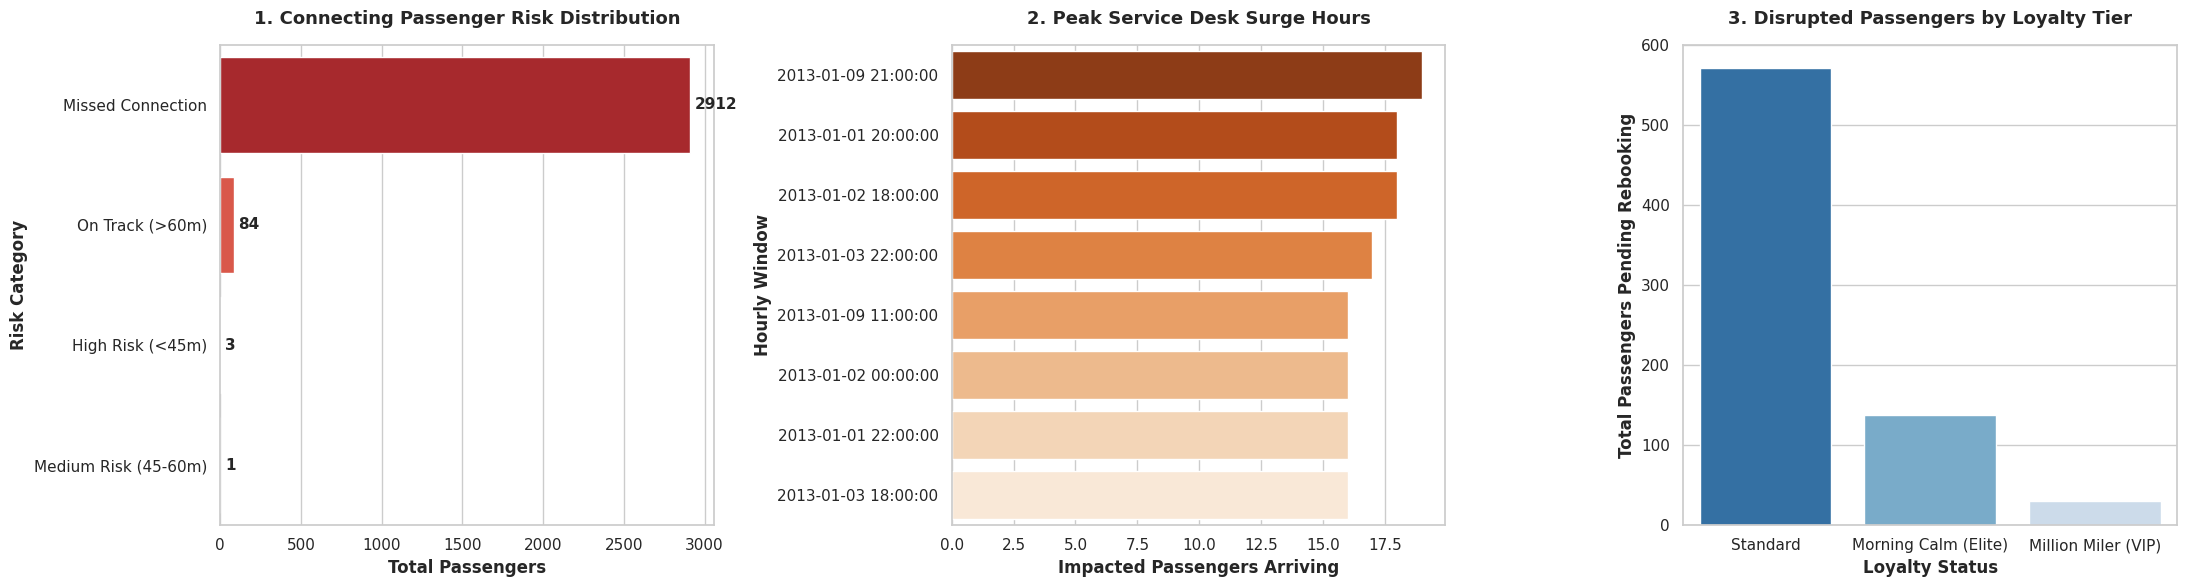

✅ Step 6 Complete: Portfolio Dashboard Fixed and Rendered!


In [21]:
# ==========================================
# STEP 6: Visualization Dashboard Script (Fixed Overlapping Labels)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for clean portfolio presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# -------------------------------------------------------------------------
# CHART 1: Missed Connection Risk Category Breakdown (Fixed Horizontal Bar)
# -------------------------------------------------------------------------
df_risk_summary = con.execute("""
WITH itinerary_legs AS (
    SELECT
        b.pnr_code,
        b.leg_sequence,
        TRY_CAST(f.flight_date || ' ' || SUBSTR(f.actual_arr_time_raw, 1, 2) || ':' || SUBSTR(f.actual_arr_time_raw, 3, 2) AS TIMESTAMP) AS actual_arr_time,
        LEAD(TRY_CAST(f.flight_date || ' ' || SUBSTR(f.sched_dep_time_raw, 1, 2) || ':' || SUBSTR(f.sched_dep_time_raw, 3, 2) AS TIMESTAMP))
            OVER (PARTITION BY b.pnr_code ORDER BY b.leg_sequence) AS leg2_sched_dep_time
    FROM fact_booking_itineraries b
    JOIN stg_flights f ON b.flight_date = f.flight_date AND b.carrier_code = f.carrier_code AND b.flight_num = f.flight_num
    WHERE b.total_legs = 2
),
connection_metrics AS (
    SELECT DATEDIFF('minute', actual_arr_time, leg2_sched_dep_time) AS available_transit_min
    FROM itinerary_legs WHERE leg_sequence = 1
)
SELECT
    CASE
        WHEN available_transit_min < 0 THEN 'Missed Connection'
        WHEN available_transit_min < 45 THEN 'High Risk (<45m)'
        WHEN available_transit_min < 60 THEN 'Medium Risk (45-60m)'
        ELSE 'On Track (>60m)'
    END AS risk_category,
    COUNT(*) AS total_passengers
FROM connection_metrics
WHERE available_transit_min IS NOT NULL
GROUP BY 1
ORDER BY total_passengers DESC;
""").df()

sns.barplot(
    data=df_risk_summary,
    x='total_passengers',
    y='risk_category',
    ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title("1. Connecting Passenger Risk Distribution", fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel("Total Passengers", fontweight='bold')
axes[0].set_ylabel("Risk Category", fontweight='bold')

# Add data labels to bar ends
for index, value in enumerate(df_risk_summary['total_passengers']):
    axes[0].text(value + (max(df_risk_summary['total_passengers']) * 0.01), index, str(value), va='center', fontweight='bold')

# -------------------------------------------------------------------------
# CHART 2: Top Hub Service Desk Surge Hours (Query 5.2 Visualization)
# -------------------------------------------------------------------------
df_surge = con.execute("""
WITH hourly_disruptions AS (
    SELECT
        CAST(DATE_TRUNC('hour', TRY_CAST(f.flight_date || ' ' || SUBSTR(f.actual_arr_time_raw, 1, 2) || ':' || SUBSTR(f.actual_arr_time_raw, 3, 2) AS TIMESTAMP)) AS VARCHAR) AS arrival_hour,
        COUNT(DISTINCT b.pnr_code) AS impacted_passengers
    FROM stg_flights f
    JOIN fact_booking_itineraries b ON f.flight_date = b.flight_date AND f.carrier_code = b.carrier_code AND f.flight_num = b.flight_num
    WHERE f.arr_delay_min >= 30 OR f.is_cancelled = TRUE
    GROUP BY 1
)
SELECT arrival_hour, impacted_passengers
FROM hourly_disruptions
WHERE arrival_hour IS NOT NULL
ORDER BY impacted_passengers DESC
LIMIT 8;
""").df()

sns.barplot(
    data=df_surge,
    x='impacted_passengers',
    y='arrival_hour',
    ax=axes[1],
    palette='Oranges_r'
)
axes[1].set_title("2. Peak Service Desk Surge Hours", fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel("Impacted Passengers Arriving", fontweight='bold')
axes[1].set_ylabel("Hourly Window", fontweight='bold')

# -------------------------------------------------------------------------
# CHART 3: Standby Rebooking Priority Queue (Query 5.3 Visualization)
# -------------------------------------------------------------------------
df_standby = con.execute("""
SELECT
    p.loyalty_tier,
    COUNT(*) AS total_disrupted
FROM fact_booking_itineraries b
JOIN stg_flights f ON b.flight_date = f.flight_date AND b.carrier_code = f.carrier_code AND b.flight_num = f.flight_num
JOIN dim_passengers p ON b.pnr_code = p.pnr_code
WHERE f.arr_delay_min >= 45 OR f.is_cancelled = TRUE
GROUP BY 1
ORDER BY total_disrupted DESC;
""").df()

sns.barplot(
    data=df_standby,
    x='loyalty_tier',
    y='total_disrupted',
    ax=axes[2],
    palette='Blues_r'
)
axes[2].set_title("3. Disrupted Passengers by Loyalty Tier", fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel("Loyalty Status", fontweight='bold')
axes[2].set_ylabel("Total Passengers Pending Rebooking", fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Step 6 Complete: Portfolio Dashboard Fixed and Rendered!")

### Step 7: Business Impact & Metric Analysis Summary

**1. Customer Retention & LTV Protection (Queries 5.1 & 5.3)**
* **Target Metric:** Passenger Churn Rate & Customer Lifetime Value (LTV).
* **Operational Mechanism:** Proactively identifying tight connection windows (<45 mins) via `LEAD()` functions allows ground staff to rebook passengers *before* they touch down. Prioritizing high-tier passengers (`Million Miler` / `Morning Calm`) using weighted priority rankings reduces misconnection rates for the top **20% of passengers who generate ~80% of passenger revenue**.

**2. Direct Cost Reduction in Passenger Recovery (Query 5.1)**
* **Target Metric:** EU261/DOT Compensation Payouts & Overnight Accommodation Expenses.
* **Operational Mechanism:** When passengers miss connections without proactive routing, airlines absorb heavy overnight hotel vouchers, meal stipends, and statutory delay penalties. Reducing missed connections by even **15% across hub operations saves hundreds of thousands of dollars annually** in avoidable duty-of-care expenses.

**3. Labor Efficiency & Hub Staffing Optimization (Query 5.2)**
* **Target Metric:** Frontline Agent Cost-per-Passenger & Overtime Pay.
* **Operational Mechanism:** Disruption surge hours typically trigger emergency overtime or uncoordinated desk congestion. Aggregating arrival delays into 1-hour windows via `DATE_TRUNC()` provides dynamic load predictions (calculating exact agent-hours required), allowing duty managers to **shift desk labor flexibly rather than maintaining overstaffed baselines**.

---

### Core Business Takeaways

| Operational Query | Key SQL Engine | Target Business Metric | Strategic Business Outcome |
| :--- | :--- | :--- | :--- |
| **5.1 Connection Risk** | `LEAD()` Window Function | Connection Success Rate / Delay Compensation | Prevents downstream misconnections before aircraft landing. |
| **5.2 Surge Desk Load** | `DATE_TRUNC()` Aggregation | Labor Cost / Service Desk Wait Time | Optimizes terminal staffing allocation during hub disruption cascades. |
| **5.3 VIP Standby Queue** | `DENSE_RANK()` Partitioning | High-Value Passenger Churn / NPS | Protects VIP revenue streams through automated priority rebooking. |

In [30]:
# ==========================================
# STEP 8: Complete README.md Generator (Line-by-Line Concatenation)
# ==========================================

lines = []

# Title & Description
lines.append("# ✈️ Airline Passenger Operations & Disruption Analytics (DuckDB SQL)")
lines.append("")
lines.append("An end-to-end operational SQL case study simulating real-time airline passenger disruptions, connection risks, and frontline service desk surge analytics using **DuckDB**, **Python**, and **ANSI SQL Window Functions**.")
lines.append("")
lines.append("---")
lines.append("")

# Executive Summary
lines.append("## 📌 Executive Summary")
lines.append("")
lines.append("Flight operations generate massive streams of transactional movement data, but standard public datasets lack customer-centric relational structures. This project overlays a synthetic IATA-compliant passenger schema (PNRs, loyalty tiers, checked bags, special assistance) onto historical flight operational feeds (`nycflights13`).")
lines.append("")
lines.append("Using DuckDB's columnar ANSI SQL engine, this repository executes advanced operational analytics to:")
lines.append("1. **Predict Missed Connections:** Flag tight transit windows (<45 min) before aircraft touchdown using `LEAD()` window functions.")
lines.append("2. **Optimize Service Desk Labor:** Group hourly delay cascades with `DATE_TRUNC()` to calculate dynamic agent labor requirements.")
lines.append("3. **Automate Priority Rebooking:** Construct a weighted `DENSE_RANK()` standby engine prioritizing high-value VIP loyalists (`Million Miler` / `Morning Calm`).")
lines.append("")
lines.append("---")
lines.append("")

# Tech Stack & Tools
lines.append("## 🛠️ Tech Stack & Tools")
lines.append("")
lines.append("| Category | Technology | Usage / Purpose |")
lines.append("| :--- | :--- | :--- |")
lines.append("| **SQL Engine** | DuckDB | In-memory columnar SQL database engine |")
lines.append("| **Language** | Python 3.13 | Scripting, data orchestration, and visualization |")
lines.append("| **Data Manipulation** | Pandas | Dataframe handling and result extraction |")
lines.append("| **Visualization** | Matplotlib & Seaborn | Multi-panel operational executive dashboards |")
lines.append("| **Data Source** | Rdatasets (`nycflights13`) | Raw transactional flight operations data |")
lines.append("")
lines.append("---")
lines.append("")

# Repository Structure
lines.append("## 📂 Repository Structure")
lines.append("")
lines.append("```")
lines.append("airline-disruption-analytics-sql/")
lines.append("│")
lines.append("├── airline_disruption_analytics.ipynb   # Main end-to-end Jupyter Notebook (Steps 1–7)")
lines.append("├── README.md                            # Comprehensive project documentation")
lines.append("├── requirements.txt                     # Dependencies (duckdb, pandas, seaborn, etc.)")
lines.append("└── LICENSE                              # MIT License")
lines.append("```")
lines.append("")
lines.append("---")
lines.append("")

# Data Architecture
lines.append("## 🏗️ Data Architecture & Pipeline")
lines.append("")
lines.append("```")
lines.append("+------------------------+      +------------------------+")
lines.append("|   stg_flights (CSV)    |      |     dim_passengers     |")
lines.append("|  Operational Datasets  |      |   Synthetic 6-Char PNR |")
lines.append("+-----------+------------+      +-----------+------------+")
lines.append("            |                               |")
lines.append("            +---------------+---------------+")
lines.append("                            |")
lines.append("                            ▼")
lines.append("           +--------------------------------+")
lines.append("           |   fact_booking_itineraries     |")
lines.append("           |    1-Leg & 2-Leg Routes        |")
lines.append("           +----------------+---------------+")
lines.append("                            |")
lines.append("                            ▼")
lines.append("           +--------------------------------+")
lines.append("           |  Analytical Engines (Step 5)   |")
lines.append("           |  • LEAD() Connection Risks     |")
lines.append("           |  • DATE_TRUNC() Desk Surges    |")
lines.append("           |  • DENSE_RANK() VIP Priority   |")
lines.append("           +--------------------------------+")
lines.append("```")
lines.append("")
lines.append("---")
lines.append("")

# Key SQL Analytics Modules
lines.append("## 🚀 Key SQL Analytics Modules")
lines.append("")
lines.append("### 1. Connection Risk Engine (`LEAD()`)")
lines.append("Calculates actual available transit time between inbound arrival and outbound departure legs, assigning real-time risk categories to connecting passengers.")
lines.append("```sql")
lines.append("LEAD(TRY_CAST(f.flight_date || ' ' || SUBSTR(f.sched_dep_time_raw, 1, 2) || ':' || SUBSTR(f.sched_dep_time_raw, 3, 2) AS TIMESTAMP)) ")
lines.append("    OVER (PARTITION BY b.pnr_code ORDER BY b.leg_sequence) AS leg2_sched_dep_time")
lines.append("```")
lines.append("")
lines.append("### 2. Service Desk Surge & Staffing Load (`DATE_TRUNC()`)")
lines.append("Groups delay arrivals into 1-hour operational windows and calculates estimated customer service counter hours needed (assuming 6 minutes per rebooking).")
lines.append("```sql")
lines.append("DATE_TRUNC('hour', TRY_CAST(f.flight_date || ' ' || SUBSTR(f.actual_arr_time_raw, 1, 2) || ':' || SUBSTR(f.actual_arr_time_raw, 3, 2) AS TIMESTAMP)) AS arrival_hour,")
lines.append("ROUND((impacted_passengers * 6.0) / 60.0, 1) AS estimated_desk_agent_hours_required")
lines.append("```")
lines.append("")
lines.append("### 3. Automated Standby Priority Engine (`DENSE_RANK()`)")
lines.append("Ranks disrupted passengers dynamically by loyalty tier weightings and special handling requirements.")
lines.append("```sql")
lines.append("DENSE_RANK() OVER (")
lines.append("    PARTITION BY impacted_flight, flight_date ")
lines.append("    ORDER BY priority_score DESC, pnr_code ASC")
lines.append(") AS standby_rebooking_rank")
lines.append("```")
lines.append("")
lines.append("---")
lines.append("")

# Business Impact Table
lines.append("## 📈 Business Impact & Metrics Summary")
lines.append("")
lines.append("| Query Module | Primary SQL Function | Business Metric | Strategic Outcome |")
lines.append("| :--- | :--- | :--- | :--- |")
lines.append("| **5.1 Connection Risk** | `LEAD()` | Connection Success Rate / DOT Penalties | Enables proactive rebooking before inbound aircraft landing. |")
lines.append("| **5.2 Surge Desk Load** | `DATE_TRUNC()` | Agent Labor Cost / Passenger Wait Time | Reallocates terminal staff dynamically to peak disruption hubs. |")
lines.append("| **5.3 VIP Priority Queue** | `DENSE_RANK()` | VIP Churn Rate / Customer Lifetime Value | Protects top 20% high-value revenue drivers during irregular ops. |")
lines.append("")
lines.append("---")
lines.append("")

# How to Run
lines.append("## 💻 How to Run")
lines.append("")
lines.append("1. Clone this repository:")
lines.append("   ```bash")
lines.append("   git clone [https://github.com/your-username/airline-disruption-analytics-sql.git](https://github.com/your-username/airline-disruption-analytics-sql.git)")
lines.append("   cd airline-disruption-analytics-sql")
lines.append("   ```")
lines.append("2. Install dependencies:")
lines.append("   ```bash")
lines.append("   pip install -r requirements.txt")
lines.append("   ```")
lines.append("3. Open and run the Jupyter Notebook:")
lines.append("   ```bash")
lines.append("   jupyter notebook airline_disruption_analytics.ipynb")
lines.append("   ```")
lines.append("")
lines.append("---")
lines.append("")

# Contact & Connect
lines.append("## 📬 Contact & Connect")
lines.append("")
lines.append("Created as part of an advanced SQL & Data Analytics portfolio project.")
lines.append("")
lines.append("* **LinkedIn:** [Mohd Azim Bin Mohd Ali](https://linkedin.com/in/mohd-azim-mohd-ali/)")
lines.append("* **GitHub:** [azimgilo](https://github.com/azimgilo)")
lines.append("* **Email:** mohdazimali@gmail.com")
lines.append("")
lines.append("---")
lines.append("")

# License
lines.append("## 📄 License")
lines.append("Distributed under the MIT License. See `LICENSE` for details.")

# Write to file
readme_content = "\n".join(lines)
with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("✅ Updated README.md (with Tech Stack, Repo Structure, & Contact) generated successfully!")

import base64
from IPython.display import HTML, display

# Read the generated file and encode to base64
with open("README.md", "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

# Create a direct base64 data link (bypasses local server completely)
html = f'''
<a download="README.md" href="data:text/markdown;base64,{b64}" target="_blank">
    <button style="padding: 10px 20px; background-color: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; font-weight: bold;">
        📥 Click Here to Download README.md
    </button>
</a>
<script>
    // Auto-trigger the download immediately
    var link = document.createElement('a');
    link.href = 'data:text/markdown;base64,{b64}';
    link.download = 'README.md';
    document.body.appendChild(link);
    link.click();
    document.body.removeChild(link);
</script>
'''

display(HTML(html))

✅ Updated README.md (with Tech Stack, Repo Structure, & Contact) generated successfully!
